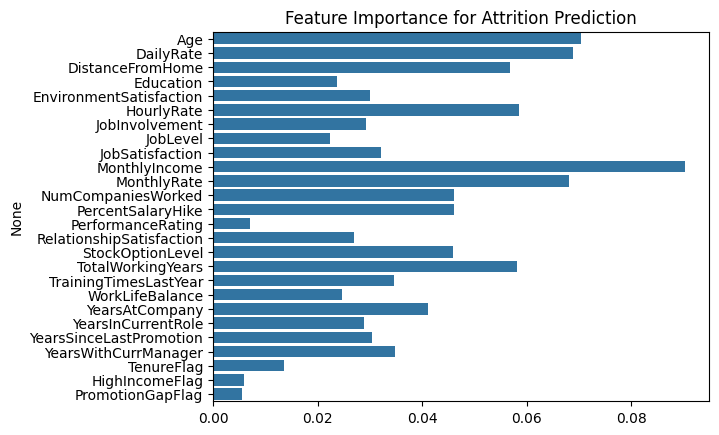

In [98]:
#IBM HR employee attrition
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report, confusion_matrix

data=pd.read_csv(r"C:\Users\Jasmine Rahaman\Desktop\vscode\jasmine\DataScienceProjects\WA_Fn-UseC_-HR-Employee-Attrition.csv")
#print(data.head(10))

df=pd.DataFrame(data)
#df=df.dropna()
#df.shape
#df.info()
#df.isnull().sum()
#df=df.dropna()
#df.head(10)

#Exploratory data analysis
#------------------------
#df['Age'].value_counts()
#sns.countplot(x=df['Age'].head(12),data=df)

#df['Attrition'].value_counts()
#sns.countplot(x=df['Attrition'],data=df)

#df['BusinessTravel'].value_counts()
#sns.countplot(x=df['BusinessTravel'],data=df)

#df['DailyRate'].value_counts()

#df['Department'].value_counts()
#sns.countplot(x=df['Department'],data=df)

#df['DistanceFromHome'].value_counts()

#['Education'].value_counts()
#sns.countplot(x=df['Education'],data=df)

#df['EducationField'].value_counts()
#sns.countplot(x=df['EducationField'],data=df)

#df['EnvironmentSatisfaction'].value_counts()
#sns.countplot(x=df['EnvironmentSatisfaction'],data=df)

#df['Gender'].value_counts()
#sns.countplot(x=df['Gender'],data=df)

#df['HourlyRate'].value_counts()
#sns.countplot(x=df['HourlyRate'],data=df)

#df['JobInvolvement'].value_counts()
#sns.countplot(x=df['JobInvolvement'],data=df)

#df['JobLevel'].value_counts()
#sns.countplot(x=df['JobLevel'],data=df)

#df['JobRole'].value_counts()
#sns.countplot(x=df['JobRole'],data=df)

#df['JobSatisfaction'].value_counts()
#sns.countplot(x=df['JobSatisfaction'],data=df)

#df['MaritalStatus'].value_counts()
#sns.countplot(x=df['MaritalStatus'],data=df)

#df['MonthlyIncome'].value_counts()
#sns.countplot(x=df['MonthlyIncome'],data=df)

#df['MonthlyRate'].value_counts()
#sns.countplot(x=df['EnvironmentSatisfaction'],data=df)

#df['NumCompaniesWorked'].value_counts()
#sns.countplot(x=df['NumCompaniesWorked'],data=df)

#df['OverTime'].value_counts()
#sns.countplot(x=df['OverTime'],data=df)

#df['PercentSalaryHike'].value_counts()
#sns.countplot(x=df['PercentSalaryHike'],data=df)

#df['PerformanceRating'].value_counts()
#sns.countplot(x=df['PerformanceRating'],data=df)

#df['RelationshipSatisfaction'].value_counts()
#sns.countplot(x=df['RelationshipSatisfaction'],data=df)

#df['StockOptionLevel'].value_counts()
#sns.countplot(x=df['StockOptionLevel'],data=df)

#df['TotalWorkingYears'].value_counts()


#df['TrainingTimesLastYear'].value_counts()
#sns.countplot(x=df['TrainingTimesLastYear'],data=df)


#df['WorkLifeBalance'].value_counts()
#sns.countplot(x=df['WorkLifeBalance'],data=df)


#df['YearsAtCompany'].value_counts()
#sns.countplot(x=df['YearsAtCompany'],data=df)

#df['YearsInCurrentRole'].value_counts()
#sns.countplot(x=df['YearsInCurrentRole'],data=df)


#df['YearsSinceLastPromotion'].value_counts()
#sns.countplot(x=df['YearsSinceLastPromotion'],data=df)

#df['YearsWithCurrManager'].value_counts()
#sns.countplot(x=df['YearsWithCurrManager'],data=df)

#EDA
# Attrition distribution 
#sns.countplot(x='Attrition', data=df) 
#plt.title("Attrition vs Non-Attrition") 
#plt.show() 

# Attrition by department 
#sns.countplot(x='Department', hue='Attrition', data=df) 
#plt.title("Attrition by Department") 
#plt.show() 

# Attrition by job satisfaction 
#sns.countplot(x='JobSatisfaction', hue='Attrition', data=df) 
#plt.title("Attrition by Job Satisfaction") 
#plt.show()

# Attrition by Age
#sns.histplot(df[df['Attrition']=='Yes']['Age'], bins=20, color='red', label='Attrition')
#sns.histplot(df[df['Attrition']=='No']['Age'], bins=20, color='yellow', label='No Attrition')
#plt.legend()
#plt.title("Attrition by Age")
#plt.show()

#Attrition by Income
#sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
#plt.title("Attrition vs Monthly Income")
#plt.show()

#Attrition by overtime
#sns.countplot(x='OverTime', hue='Attrition', data=df)
#plt.title("Attrition by Overtime")
#plt.show()


#Attrition by Tenure
#sns.histplot(df[df['Attrition']=='Yes']['YearsAtCompany'], bins=20, color='red', label='Attrition')
#sns.histplot(df[df['Attrition']=='No']['YearsAtCompany'], bins=20, color='blue', label='No Attrition')
#plt.legend()
#plt.title("Attrition by Years at Company")
#plt.show()


#feature engineering
# Tenure flag
df['TenureFlag'] = df['YearsAtCompany'].apply(lambda x: 1 if x < 2 else 0)

# High income flag
df['HighIncomeFlag'] = (df['MonthlyIncome'] > df['MonthlyIncome'].median()).astype(int)

# Promotion gap flag
df['PromotionGapFlag'] = (df['YearsSinceLastPromotion'] > 3).astype(int)

features = [col for col in df.columns if col not in ['Attrition','BusinessTravel','Department','EducationField','Gender','JobRole','MaritalStatus','OverTime']]
X = df[features]
y = df['Attrition'].map({'No':0,'Yes':1})

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

#print(classification_report(y_test,y_pred))
#print(confusion_matrix(y_test,y_pred))


#visualization of insights
importances = model.feature_importances_
features_list = X.columns

sns.barplot(x=importances, y=features_list)
plt.title("Feature Importance for Attrition Prediction")
plt.show()
